### **Phase 1: Business Understanding**

Goal: 

✅ True (ซื้อสินค้า): เซสชันนี้จบลงที่หน้า Thank You หรือมีการตัดบัตรจ่ายเงินสำเร็จ

❌ False (ไม่ซื้อสินค้า): เซสชันนี้จบลงด้วยการปิดเว็บหนีไปมือเปล่า (Drop-off)

### **Phase 2: Data Understanding**

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import warnings

In [29]:
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [30]:
df_raw = pd.read_csv('../data/raw/online_shoppers_intention.csv')
df_raw.head(20)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.00,0,0.00,6,1156.50,0.00,0.03,0.00,0.00,Nov,2,2,1,20,Returning_Visitor,False,False
1,4,52.00,1,7.00,46,3087.00,0.00,0.02,16.95,0.00,Mar,2,2,3,8,Returning_Visitor,False,True
2,4,106.50,0,0.00,12,806.25,0.01,0.03,0.00,0.00,Dec,2,2,1,2,Returning_Visitor,False,False
3,9,497.17,0,0.00,20,1170.17,0.01,0.02,0.00,0.00,Nov,3,2,3,2,Returning_Visitor,False,False
4,0,0.00,0,0.00,3,17.00,0.00,0.03,0.00,0.00,Mar,1,1,1,3,Returning_Visitor,False,False
5,0,0.00,0,0.00,12,363.00,0.02,0.05,0.00,0.00,Nov,4,1,4,2,Returning_Visitor,False,False
6,1,11.50,1,94.00,98,6212.78,0.02,0.03,0.00,0.00,Nov,3,2,4,10,Returning_Visitor,True,False
7,9,174.21,2,383.75,151,9018.12,0.01,0.02,0.00,0.00,Nov,1,2,1,1,Returning_Visitor,True,False
8,0,0.00,0,0.00,9,165.00,0.00,0.02,0.00,1.00,May,2,2,4,4,Returning_Visitor,True,False
9,0,0.00,0,0.00,6,118.33,0.03,0.04,0.00,0.00,Nov,3,2,1,3,Returning_Visitor,True,False


In [31]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

In [32]:
df_raw.nunique()

Administrative               27
Administrative_Duration    3335
Informational                17
Informational_Duration     1258
ProductRelated              311
ProductRelated_Duration    9551
BounceRates                1872
ExitRates                  4777
PageValues                 2704
SpecialDay                    6
Month                        10
OperatingSystems              8
Browser                      13
Region                        9
TrafficType                  20
VisitorType                   3
Weekend                       2
Revenue                       2
dtype: int64

In [33]:
df_raw.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [34]:
df_raw.select_dtypes(include=['object', 'category']).columns

Index(['Month', 'VisitorType'], dtype='str')

In [35]:
text_cols = df_raw.select_dtypes(include=['object', 'category']).columns
for col in text_cols:
    print(f"Unique values in '{col}': {df_raw[col].unique()}")

Unique values in 'Month': <ArrowStringArray>
['Nov', 'Mar', 'Dec', 'May', 'Aug', 'Jul', 'Feb', 'June', 'Sep', 'Oct']
Length: 10, dtype: str
Unique values in 'VisitorType': <ArrowStringArray>
['Returning_Visitor', 'New_Visitor', 'Other']
Length: 3, dtype: str


### **Phase 3: Exploratory Data Analysis**

In [36]:
plt.figure(figsize=(10, 8))
sns.set_style('whitegrid')

<Figure size 1000x800 with 0 Axes>

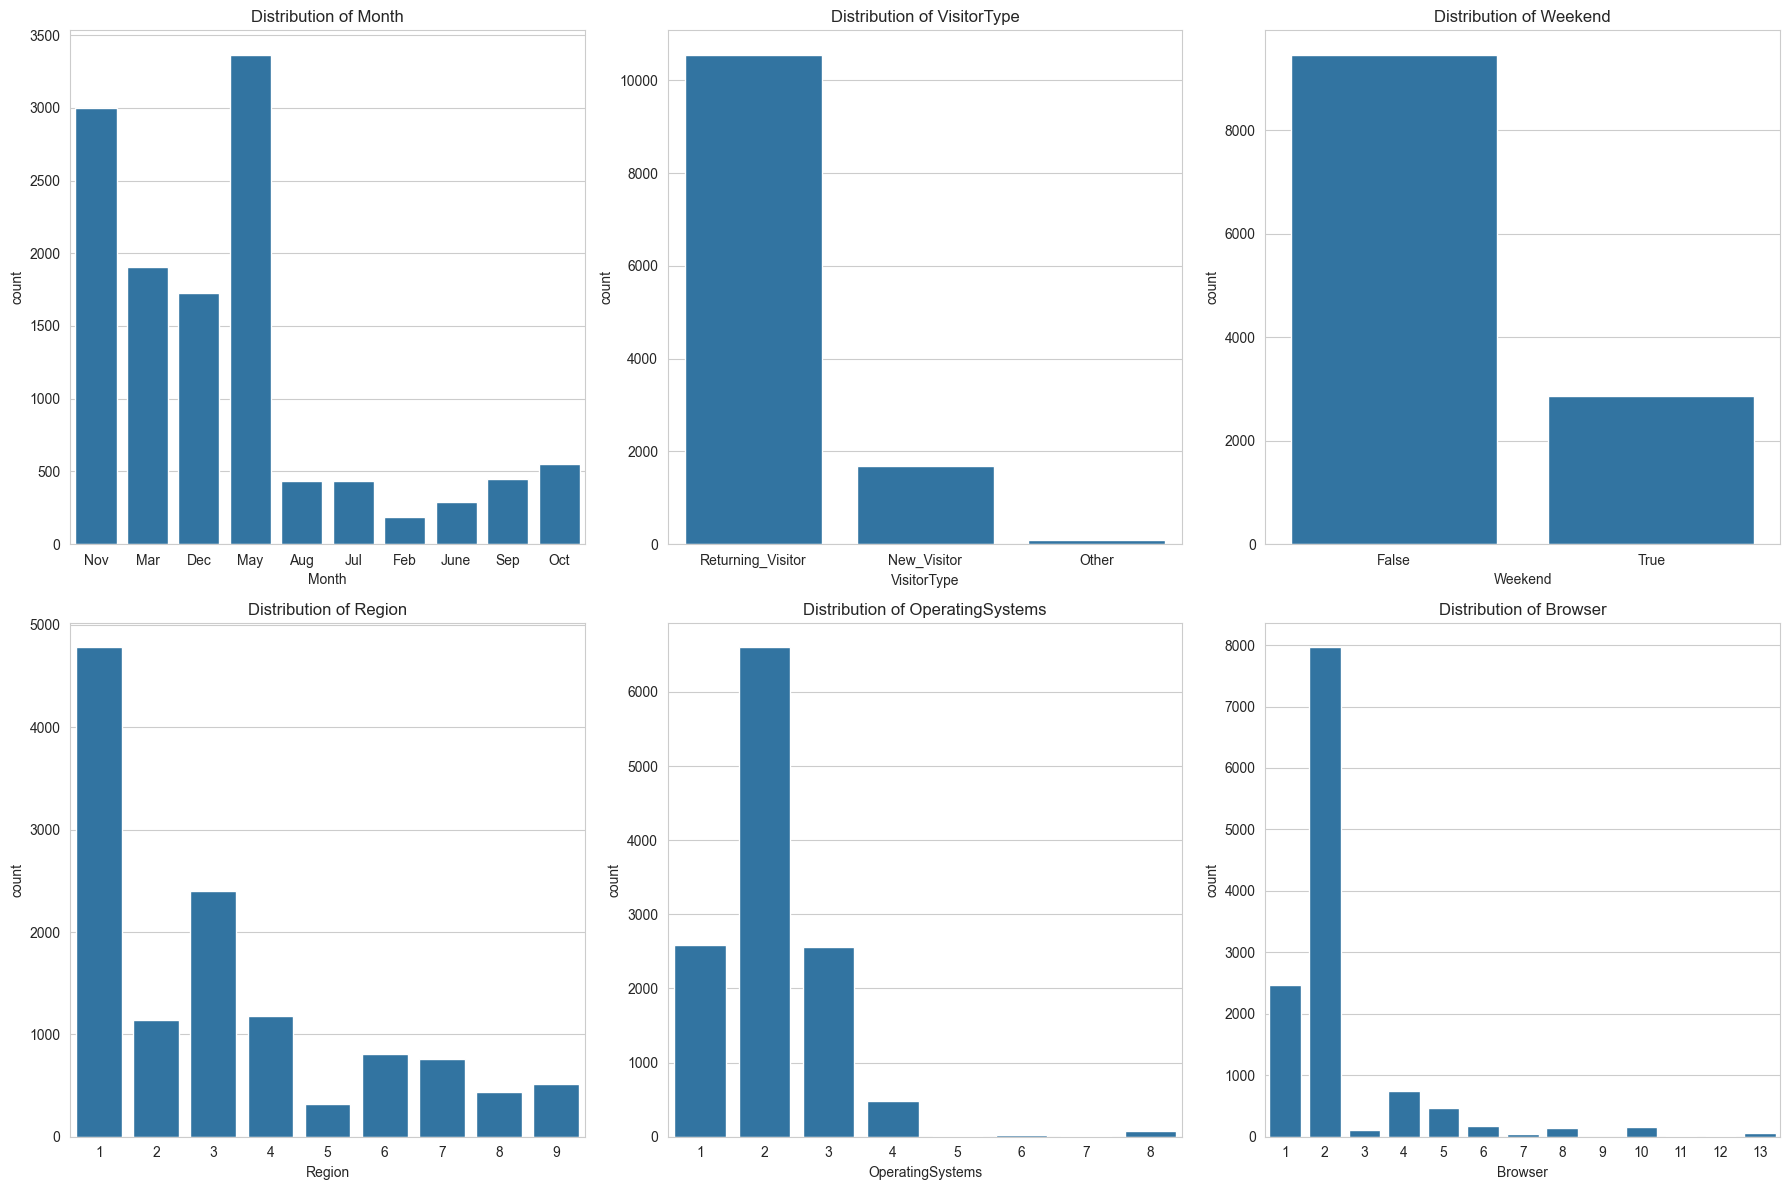

In [37]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
sns.countplot(x='Month', data=df_raw, ax=axes[0 ,0])
axes[0, 0].set_title('Distribution of Month')
sns.countplot(x='VisitorType', data=df_raw, ax=axes[0, 1])
axes[0, 1].set_title('Distribution of VisitorType')
sns.countplot(x='Weekend', data=df_raw, ax=axes[0, 2])
axes[0, 2].set_title('Distribution of Weekend')
sns.countplot(x='Region', data=df_raw, ax=axes[1, 0])
axes[1, 0].set_title('Distribution of Region')
sns.countplot(x='OperatingSystems', data=df_raw, ax=axes[1, 1])
axes[1, 1].set_title('Distribution of OperatingSystems')
sns.countplot(x='Browser', data=df_raw, ax=axes[1, 2])
axes[1, 2].set_title('Distribution of Browser')
plt.tight_layout()
plt.show()

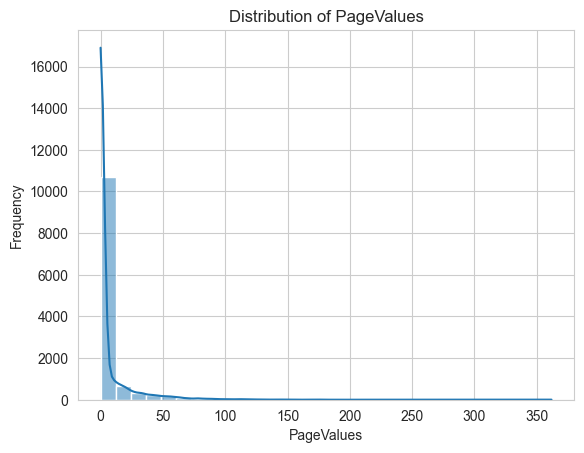

In [38]:
sns.histplot(df_raw['PageValues'], bins=30, kde=True)
plt.title('Distribution of PageValues')
plt.xlabel('PageValues')
plt.ylabel('Frequency')
plt.show()

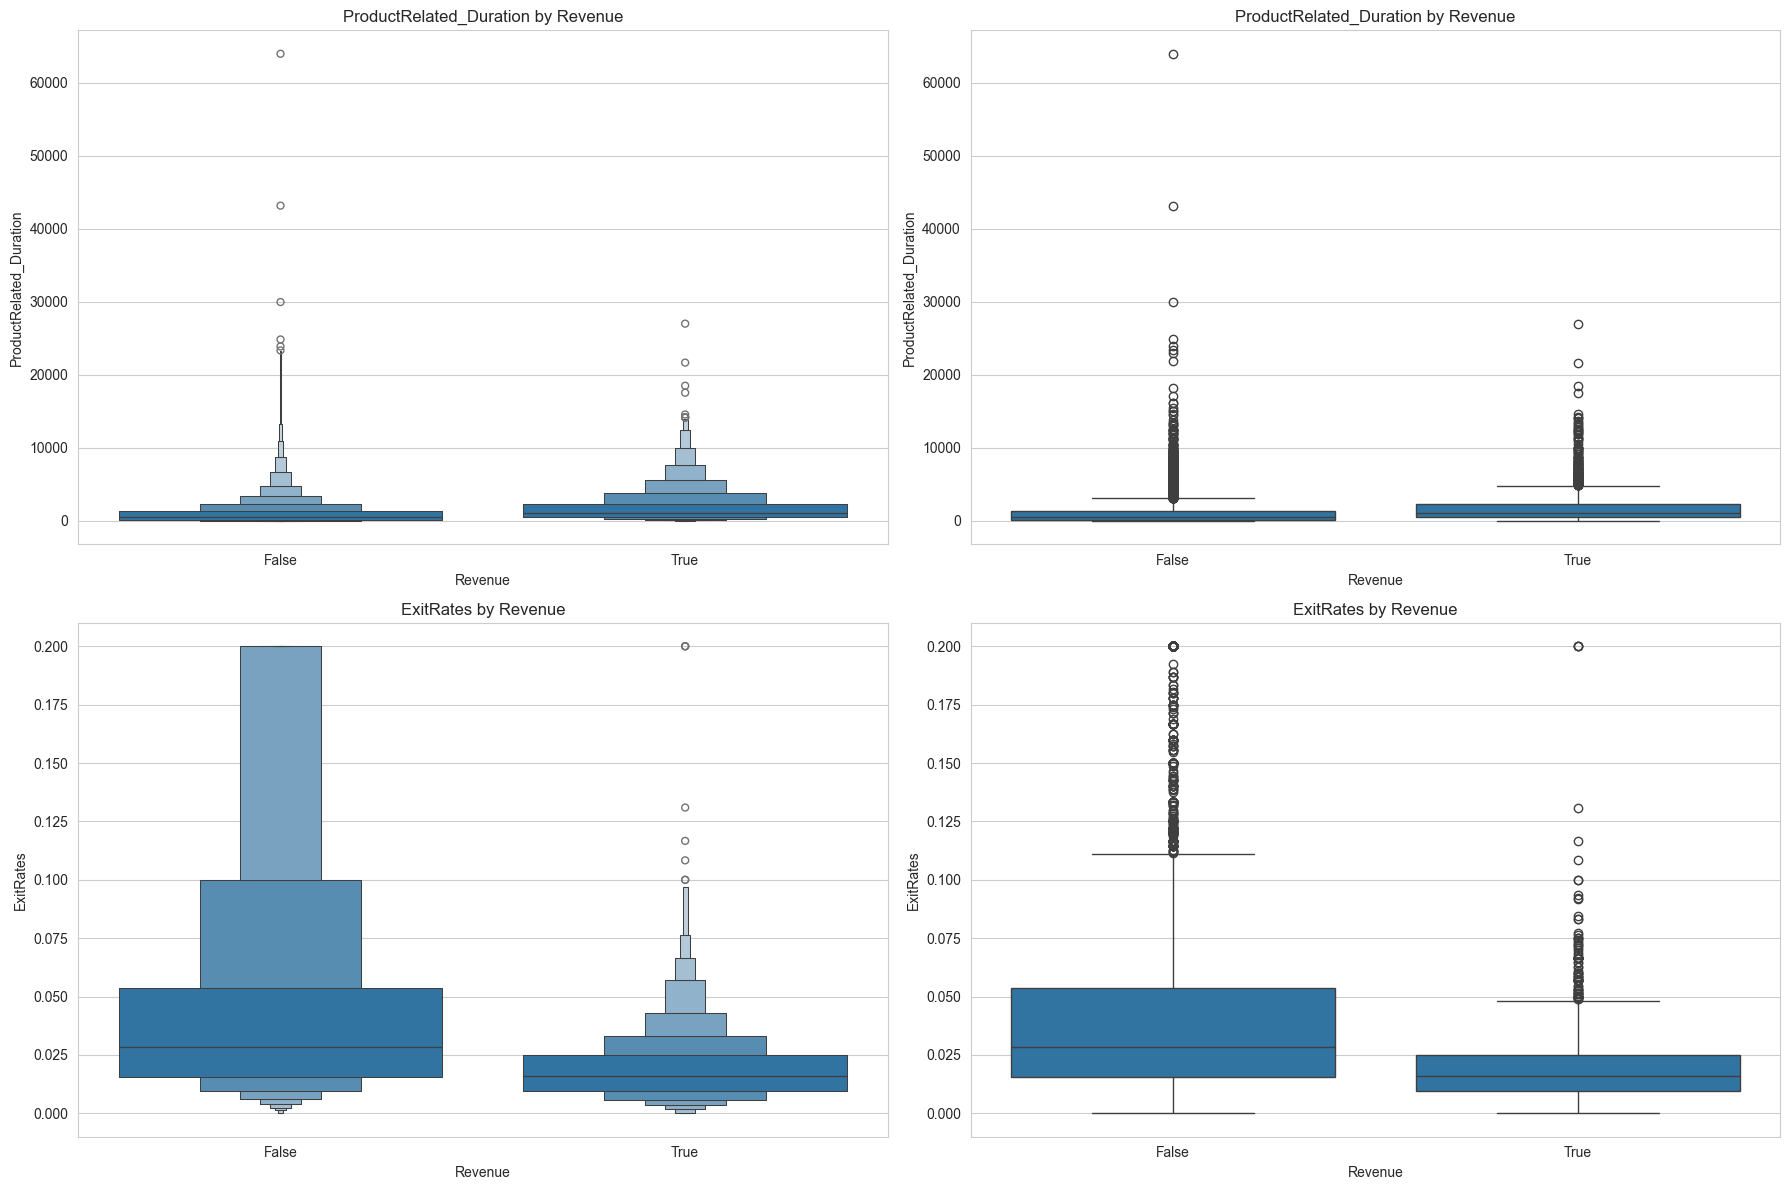

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
sns.boxenplot(x='Revenue', y='ProductRelated_Duration', data=df_raw, ax=axes[0, 0])
axes[0, 0].set_title('ProductRelated_Duration by Revenue')
sns.boxplot(x='Revenue', y='ProductRelated_Duration', data=df_raw, ax=axes[0, 1])
axes[0, 1].set_title('ProductRelated_Duration by Revenue')
sns.boxenplot(x='Revenue', y='ExitRates', data=df_raw, ax=axes[1, 0])
axes[1, 0].set_title('ExitRates by Revenue')
sns.boxplot(x='Revenue', y='ExitRates', data=df_raw, ax=axes[1, 1])
axes[1, 1].set_title('ExitRates by Revenue')
plt.tight_layout()
plt.show()



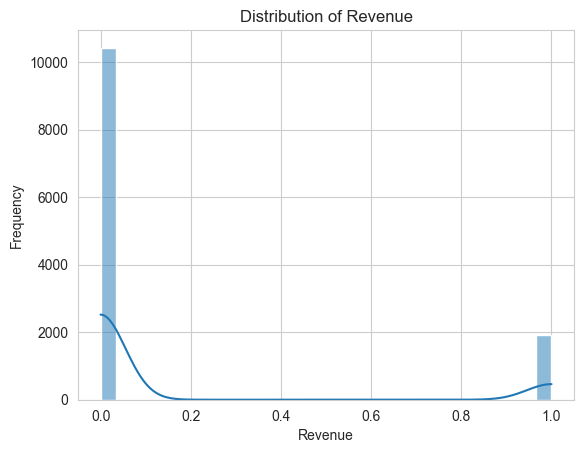

In [40]:
sns.histplot(df_raw['Revenue'], bins=30, kde=True)
plt.title('Distribution of Revenue')
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.show()

### **Phase 4: Data Wrangling**

In [41]:
df_processed =df_raw.copy()
df_processed.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.00,0,0.00,6,1156.50,0.00,0.03,0.00,0.00,Nov,2,2,1,20,Returning_Visitor,False,False
1,4,52.00,1,7.00,46,3087.00,0.00,0.02,16.95,0.00,Mar,2,2,3,8,Returning_Visitor,False,True
2,4,106.50,0,0.00,12,806.25,0.01,0.03,0.00,0.00,Dec,2,2,1,2,Returning_Visitor,False,False
3,9,497.17,0,0.00,20,1170.17,0.01,0.02,0.00,0.00,Nov,3,2,3,2,Returning_Visitor,False,False
4,0,0.00,0,0.00,3,17.00,0.00,0.03,0.00,0.00,Mar,1,1,1,3,Returning_Visitor,False,False


In [42]:
df_processed = pd.get_dummies(df_processed, columns=['Month', 'VisitorType', 'Region', 'Browser', 'OperatingSystems', 'TrafficType'], drop_first=True, dtype=int)
df_processed.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Weekend,Revenue,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor,Region_2,Region_3,Region_4,Region_5,Region_6,Region_7,Region_8,Region_9,Browser_2,Browser_3,Browser_4,Browser_5,Browser_6,Browser_7,Browser_8,Browser_9,Browser_10,Browser_11,Browser_12,Browser_13,OperatingSystems_2,OperatingSystems_3,OperatingSystems_4,OperatingSystems_5,OperatingSystems_6,OperatingSystems_7,OperatingSystems_8,TrafficType_2,TrafficType_3,TrafficType_4,TrafficType_5,TrafficType_6,TrafficType_7,TrafficType_8,TrafficType_9,TrafficType_10,TrafficType_11,TrafficType_12,TrafficType_13,TrafficType_14,TrafficType_15,TrafficType_16,TrafficType_17,TrafficType_18,TrafficType_19,TrafficType_20
0,0,0.00,0,0.00,6,1156.50,0.00,0.03,0.00,0.00,False,False,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1,4,52.00,1,7.00,46,3087.00,0.00,0.02,16.95,0.00,False,True,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
2,4,106.50,0,0.00,12,806.25,0.01,0.03,0.00,0.00,False,False,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,9,497.17,0,0.00,20,1170.17,0.01,0.02,0.00,0.00,False,False,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0.00,0,0.00,3,17.00,0.00,0.03,0.00,0.00,False,False,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [43]:
df_processed.nunique()

Administrative                     27
Administrative_Duration          3335
Informational                      17
Informational_Duration           1258
ProductRelated                    311
ProductRelated_Duration          9551
BounceRates                      1872
ExitRates                        4777
PageValues                       2704
SpecialDay                          6
Weekend                             2
Revenue                             2
Month_Dec                           2
Month_Feb                           2
Month_Jul                           2
Month_June                          2
Month_Mar                           2
Month_May                           2
Month_Nov                           2
Month_Oct                           2
Month_Sep                           2
VisitorType_Other                   2
VisitorType_Returning_Visitor       2
Region_2                            2
Region_3                            2
Region_4                            2
Region_5    

In [44]:
df_processed['Weekend'] = df_processed['Weekend'].astype(int)
df_processed['Revenue'] = df_processed['Revenue'].astype(int)

In [45]:
corr_matrix = df_processed.corr(numeric_only=True)
revenue_corr = corr_matrix['Revenue'].sort_values(ascending=False)
print("Correlation of features with Revenue:")
print(revenue_corr)


Correlation of features with Revenue:
Revenue                          1.00
PageValues                       0.49
ProductRelated                   0.16
Month_Nov                        0.15
ProductRelated_Duration          0.15
Administrative                   0.14
TrafficType_2                    0.12
Informational                    0.10
Administrative_Duration          0.09
Informational_Duration           0.07
OperatingSystems_2               0.06
TrafficType_8                    0.06
TrafficType_20                   0.03
Month_Oct                        0.03
Weekend                          0.03
TrafficType_5                    0.02
TrafficType_10                   0.02
TrafficType_7                    0.02
Browser_13                       0.02
Month_Sep                        0.02
Browser_5                        0.02
Browser_4                        0.02
TrafficType_11                   0.01
OperatingSystems_8               0.01
Browser_10                       0.01
OperatingSys

In [46]:
SAVE_PATH = '../data/processed/online_shoppers_intention_processed.csv'
os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)
df_processed.to_csv(SAVE_PATH, index=False)
print(f"Processed data saved to {SAVE_PATH}")


Processed data saved to ../data/processed/online_shoppers_intention_processed.csv
